<a href="https://www.kaggle.com/code/bhaveshyadav111/stroke-prediction-engine?scriptVersionId=338491859" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np 


# Libararies required

In [ ]:
!pip install imbalanced-learn --quiet

In [ ]:
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_curve,roc_auc_score
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
from pathlib import Path

In [ ]:
data_path = Path('/kaggle/input/datasets/fedesoriano/stroke-prediction-dataset')
data_path

In [ ]:
import os
os.listdir(data_path)

In [ ]:
df = pd.read_csv(f'{data_path}/healthcare-dataset-stroke-data.csv')

In [ ]:
df.sample(5)

# EDA

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.head()

In [ ]:
df.isna().sum()

In [ ]:
px.scatter(df,x='age',y='avg_glucose_level',color='smoking_status')

In [ ]:
px.scatter(df,x='age',y='bmi',color='work_type')

as the data shown above , can conclude that people in private work have a low or standard/ balanced BMI as compared to people working in government jobs.

But we can't conclude children and never - worked data because few data is present here about these.

In [ ]:
sns.barplot(df,x='ever_married',y='stroke')

One unexpected feature that is Ever_married affects a lot whether a person has stroke or not . From analysis we conclude married person have high chances of stroke.

In [ ]:
sns.barplot(df,x='bmi',y='work_type')

In [ ]:
sns.barplot(df,x='stroke',y='Residence_type')

As we look at Residence type of people , the people who live in Urban areas have more probability stroke

In [ ]:
df.Residence_type.value_counts()

In [132]:
names = ['Urban','Rural']

In [ ]:
plt.pie(df.Residence_type.value_counts(),labels=names,autopct='%1.2f%%')

In [ ]:
stroke_name = ['no','yes']

In [133]:
df.stroke.value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [ ]:
plt.pie(df.stroke.value_counts(),labels=stroke_name,autopct='%1.2f%%')

In [ ]:
px.histogram(df,'stroke')

our data is bias , needs to follow some steps 

-> Penalize the majority class

-> Use alogrithm robust to imbalancement like Random Forest , XGBoost

In [ ]:
df.corr(numeric_only=True)['stroke'].sort_values(ascending=False)

# Preprocessing

As the data is imbalance , let's try to make it balance by using Undersampling and Oversampling and see how it affects the prediction of different models.

In [115]:
df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [ ]:
df.bmi.fillna(df.bmi.mean(),inplace=True)

## input & Output selection

In [ ]:
input_cols = df.columns[1:-1].tolist()
target = 'stroke'

## train ,validation & test split

In [ ]:
train_val,test = train_test_split(df,test_size=0.25,random_state=1)
train,val = train_test_split(train_val,test_size=0.25,random_state=1)

x_train = train[input_cols]
x_val = val[input_cols]
x_test = test[input_cols]

y_train = train[target]
y_val = val[target]
y_test = test[target]

## Identify Numerical and Categorical features 

In [ ]:
num_cols = x_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = x_train.select_dtypes(include='object').columns.tolist()

### adjust features type

In [ ]:
num_cols = ['age','avg_glucose_level','bmi']

As , get biased data needs to handle it with OverSampling using -> SMOTENC(Synthetic Minority Over-sampling technique for nominal and categorical features)

In [ ]:
over = SMOTENC(categorical_features=cat_cols,random_state=1)
x_train,y_train = over.fit_resample(x_train[input_cols],y_train)

After Oversampling the new Data looks like :

In [ ]:
temp_df = x_train.copy()
temp_df['stroke'] = y_train.copy()
# Data plot after oversampling
plt.pie(temp_df.stroke.value_counts(),labels=stroke_name,autopct='%1.2f%%')

### Handling Numerical features

In [ ]:
num_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

### handling Categorical features

In [ ]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer([
    ('num',num_pipe,num_cols),
    ('cat',cat_pipe,cat_cols)
])


# Models(ALGORITHMs)

In [ ]:
# models 
lg = Pipeline([
    ('preprocess',preprocessor),
    ('lgCV_model',LogisticRegressionCV(max_iter=1000,cv=5,solver='lbfgs'))
])

nb = Pipeline([
    ('preprocess',preprocessor),
    ('nb_model',GaussianNB())
])

svc = Pipeline([
    ('preprocess',preprocessor),
    ('svc_model',SVC(kernel='linear'))
])

dt = Pipeline([
    ('preprocess',preprocessor),
    ('Dt_model',DecisionTreeClassifier(max_depth=4,random_state=1))
])

rdf = Pipeline([
    ('preprocess',preprocessor),
    ('rdf_model',RandomForestClassifier(n_estimators=200,bootstrap=True,random_state=1))
])

In [ ]:
print('RECALL_SCORE')
print('*************')

for model,name in [(lg,'logisticCV'),(nb,'Naive Bayes'),(svc,"SVM"),(dt,'Decision Tree'),(rdf,'Random Forest')]:
    model.fit(x_train,y_train)

    print(name)
    pred_train = model.predict(x_train)
    pred_val = model.predict(x_val)
    pred_test = model.predict(x_test)
    print('-------------------------------')
    print('train acc :',recall_score(y_train,pred_train))
    print('val acc :',recall_score(y_val,pred_val))
    print('test acc :',recall_score(y_test,pred_test))
    print('-------------------------------')
    

# HyperParam tuning

In [ ]:
!pip install joblib --quiet

In [ ]:
for kr in ['linear','poly','rbf','sigmoid'] : 
    svc = Pipeline([
        ('preprocess',preprocessor),
        ('svc_model',SVC(kernel= kr))
    ])
    svc.fit(x_train,y_train)
    y_pred = svc.predict(x_test)
    print(recall_score(y_test,y_pred))

For SVC linear kernel function is best.

## LogisticRegressionCV Decision Tree and Random Forest Tuning

In [ ]:
params = {
    'Dt_model__max_depth' : [depth for depth in range(3,10)],
    'Dt_model__min_samples_split' : [split for split in range(2,15)],
    'Dt_model__ccp_alpha' : [0.01,0.1,0.3,0.5,1],
    'Dt_model__max_features' : [maxF/10 for maxF in range(3,9)]
}
dt_final = RandomizedSearchCV(dt,param_distributions=params,cv=5,n_iter=20,scoring="recall",random_state=1).fit(x_train,y_train)

In [ ]:
dt_final.best_params_

In [131]:
y_pred = dt_final.predict(x_test)
print('test_acc',recall_score(y_test,y_pred))
print('roc_auc_score ',roc_auc_score(y_test,y_pred))

test_acc 0.9466666666666667
roc_auc_score  0.7767414796342478


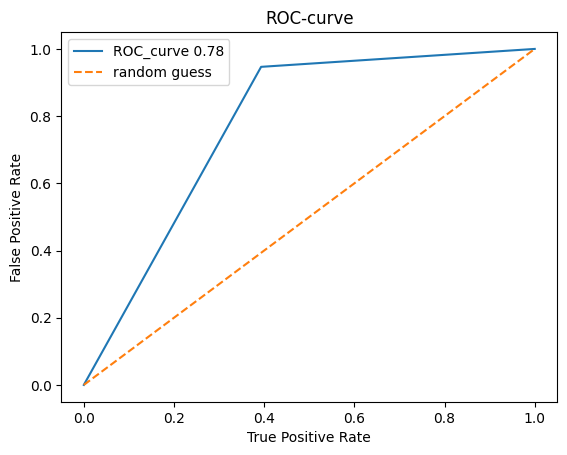

In [127]:
fpr,tpr,thersholds = roc_curve(y_test,y_pred)
plt.title("ROC-curve")
plt.plot(fpr,tpr,label=f'ROC_curve {roc_auc_score(y_test,y_pred):.2f}')
plt.plot([0,1],[0,1],linestyle='--',label="random guess")

plt.xlabel('True Positive Rate')
plt.ylabel('False Positive Rate')
plt.legend()

In [142]:
params = {
    'rdf_model__max_depth' : [depth for depth in range(3,10)],
    'rdf_model__min_samples_split' : [split for split in range(2,15)],
    'rdf_model__ccp_alpha' : [0.01,0.1,0.3,0.5,1],
    'rdf_model__max_features' : [maxF/10 for maxF in range(3,9)]
}
rdf_final = RandomizedSearchCV(rdf,param_distributions=params,n_iter=20,scoring='recall',cv=5,random_state=1).fit(x_train,y_train)

In [144]:
rdf_final.best_params_

{'rdf_model__min_samples_split': 10,
 'rdf_model__max_features': 0.6,
 'rdf_model__max_depth': 9,
 'rdf_model__ccp_alpha': 0.1}

In [145]:
rdf_final.score(x_train,y_train)

0.9231609613983977

In [143]:
y_pred = rdf_final.predict(x_test)
print(recall_score(y_test,y_pred))
print('roc_auc_score ',roc_auc_score(y_test,y_pred))

0.9466666666666667
roc_auc_score  0.7767414796342478


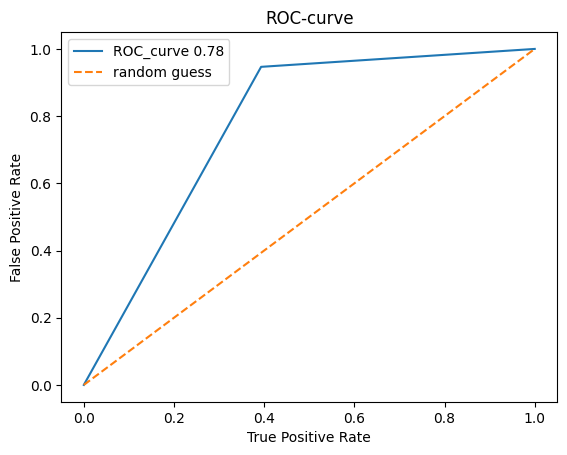

In [129]:
fpr,tpr,thersholds = roc_curve(y_test,y_pred)
plt.title("ROC-curve")
plt.plot(fpr,tpr,label=f'ROC_curve {roc_auc_score(y_test,y_pred):.2f}')
plt.plot([0,1],[0,1],linestyle='--',label="random guess")

plt.xlabel('True Positive Rate')
plt.ylabel('False Positive Rate')
plt.legend()

In [ ]:
lg = Pipeline([
    ('preprocess',preprocessor),
    ('lgCV_model',LogisticRegressionCV(max_iter=500,cv=5,solver='lbfgs'))
])
params = {
    'lgCV_model__cv' : [5,7,10],
    'lgCV_model__Cs' : [c for c in range(2,10)]
}
lg_final = RandomizedSearchCV(lg,param_distributions=params,n_iter=20,scoring='recall',cv=5,random_state=1).fit(x_train,y_train)


In [ ]:
lg_final.best_params_

In [ ]:
y_pred = lg_final.predict(x_train)
print(recall_score(y_train,y_pred))

In [ ]:
import joblib
models = {
    "rdf_final" : rdf_final,
    "dt_final" : dt_final,
    "nb" : nb,
    "svc" : svc
}
joblib.dump(models,"models")

In [ ]:
load_models = joblib.load("models")
load_models.keys()

# Voting and Stacking Classifiers


In [ ]:
from sklearn.ensemble import VotingClassifier

final_model = VotingClassifier(estimators=[
    ('lg',lg_final),
    ('dt',dt_final),
    ('rdf',rdf_final),
    ('nb',nb)
],voting='soft')

final_model.fit(x_train,y_train)

pred_train = final_model.predict(x_train)
pred_val = final_model.predict(x_val)
pred_test = final_model.predict(x_test)
print('-------------------------------')
print('train acc :',recall_score(y_train,pred_train))
print('val acc :',recall_score(y_val,pred_val))
print('test acc :',recall_score(y_test,pred_test))
print('-------------------------------')

In [ ]:
from sklearn.ensemble import StackingClassifier

stack_model = StackingClassifier(
    estimators=[
        ('lg',lg_final),
        ('rdf',rdf_final),
        ('nb',nb)
    ],
    final_estimator=dt_final,
    cv = 5
)

stack_model.fit(x_train,y_train)

pred_train = stack_model.predict(x_train)
pred_val = stack_model.predict(x_val)
pred_test = stack_model.predict(x_test)
print('-------------------------------')
print('train acc :',recall_score(y_train,pred_train))
print('val acc :',recall_score(y_val,pred_val))
print('test acc :',recall_score(y_test,pred_test))
print('-------------------------------')